# Module 6: Introduction to Vision Transformers

<text style="background-color:red"> **Before you run any of the code blocks**:</text>
1. Go to `Runtime>Change runtime type` and select `T4 GPU` as the hardware accelerator.

2. Run the code block below to download your data. This code blocks installs the dataset from Kaggle and then unzips it. This should take ~5 minutes. Read the overview in the meantime.

In [ ]:
!curl -L -o breast-histopathology-images.zip\
  https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/breast-histopathology-images
!unzip -q breast-histopathology-images.zip -d .

## Overview

Welcome to the vision section of the course! In modules 6 & 7, we will explore the current state-of-the-art method for computer vision tasks, the Vision Transformer (ViT). ViTs can be used for a variety of tasks, including image classification, object detection, and segmentation. Keeping with the course theme, we will explore how we could use a ViT to classify Whole Mount Slide Images (WSIs) of breast histology slides as either benign or malignant.

1. Setup
- Library Imports
- Device selection
- Kaggle API

2. Investigating the Dataset
- Download the Dataset from Kaggle (or import from Google Drive, TBD)
- Invasive Ductal Carcinoma (IDC) Dataset
- Dataset Structure
- Be a Pathologist

3. Introduction to the Vision Transformer
- What is a Vision Transformer?
- What is the attention mechanism?
- What is the basic architecture of a Vision Transformer?

4. Running Inference
- How to instantiate a model using timm
- Introduction to the Dice score

## Setup

### Library Loading

In [ ]:
import os, re, random, json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.utils.data._utils.collate import default_collate
import timm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from importlib import reload

from patch_dataset import PatchDataset

import matplotlib.pyplot as plt
from skimage.io import imread

import warnings

random.seed(42) # For reproducibility

### Device

For larger machine learning models, we typically use a GPU to speed up training and inference. `PyTorch` is written to be compatible with `CUDA`, which in simple terms, is a language that allows us to run code directly on the GPU. This speeds things up significantly.

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

*Please note*: this activity will not be feasible to be completed on a CPU. If you are having trouble getting a GPU, please let a TA know.

## Investigating the Dataset

### Invasive Ductal Carcinoma (IDC)

When developing **machine learning models** to detect cancers, it's important to understand the data we are working with.

Invasive Ductal Carcinoma (IDC) is the most common type of breast cancer, accounting for approximately 80% of all invasive breast cancer diagnoses. Biologically, IDC begins in the milk ducts of the breast and invades the surrounding breast tissue, with the potential to spread to lymph nodes and other parts of the body.

Patients with IDC may present with symptoms such as a palpable lump in the breast, changes in breast shape or size, skin dimpling, nipple discharge, or pain. However, in some cases, IDC may be asymptomatic and detected only through routine imaging, such as mammography.

<figure>
<img src="images/idc_graphic.png" alt="IDC Graphic" width="600">
<figcaption><strong>Figure 1:</strong> Graphic depicting the difference between a breast with IDC and a healthy breast.
</figure>

### Histology and Staining

To provide diagnoses, pathologists will often perform an H&E stain on a biopsy of the tissue.

The `H` in H&E stands for hematoxylin, which is a dye that binds to the nuclei of cells.

The `E` in H&E stands for eosin, which is a dye that binds to the cytoplasm of cells.

The combination of these two dyes creates a contrast between the nuclei and the cytoplasm of cells, making them easier to see.

On histology, IDC is characterized by malignant epithelial cells forming irregular glandular structures or sheets that invade the surrounding stromal tissue. The tumor cells often exhibit pleomorphism, hyperchromatic nuclei, and increased mitotic activity. The surrounding stroma may show a desmoplastic reaction, and lymphovascular invasion may also be observed in more aggressive cases.

<figure>
<img src="images/idc_histology_example.jpg" alt="IDC Graphic" width="600">
<figcaption><strong>Figure 2:</strong> An example of an H&E stain for a biopsy of a breast with IDC.
</figure>

### Dataset Structure

You may have noticed that there are a lot of files in the dataset. This is because we are working with Whole Slide Images (WSIs), which are large images that can be hard to process as a whole. In the field of computational pathology, we often break these WSIs into smaller areas called **patches**, which allow us to process smaller fields of view at a time.

The dataset you downloaded is formatted as follows: ```Directory_Containing_Images/Whole_Slide_Image_ID/Status_Binary/Path_Filename.png```

Where:
- `Directory_Containing_Images`: The directory containing the images.
- `Whole_Slide_Image_ID`: The ID of the whole slide image (WSI).
- `Status_Binary`: The status of the WSI, either `benign`, 0 or `malignant`, 1.
- `Path_Filename.png`: The filename of patch itself, where `xcor` and `ycor` are the coordinates of the patch in the WSI

So for example, ```IDC_regular_ps50_idx5/8913/0/8913_idx5_x201_y1051_class0.png``` follows:
- `IDC_regular_ps50_idx5`: The directory containing the images.
- `8913`: The ID of the whole slide image (WSI).
- `0`: indicating that the WSI is benign.
- `8913_idx5_x201_y1051_class0.png`: The filename of patch itself, and indicating that the x-coordinate is 201 and the y-coordinate is 1051.

For our inference purposes, we will treat each patch as a separate entity that we can classify as either benign or malignant.

### Dataset Class

Below is the code for the `PatchDataset` class, which is used to load the dataset. Run this code block.

In [ ]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset

class PatchDataset(Dataset):
    """
    Stand-alone dataset so DataLoader workers can import it.

    Args
    ----
    df      : pandas.DataFrame with columns path, label, wsi_id, x, y
    tfms    : torchvision transform pipeline
    """
    def __init__(self, df, tfms):
        self.df   = df.reset_index(drop=True)
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row.path).convert("RGB")
        img   = self.tfms(img)
        label = torch.tensor(row.label, dtype=torch.float32)  # BCEWithLogits
        meta  = (row.wsi_id, row.x, row.y)
        return img, label, meta

### Formatting Dataset

The following code will create a `pandas` dataframe containing the `wsi_id`, `xcor`, `ycor`, `label`, and `path` of each patch.

**After you download the dataset**, please locate it, get the file path, and then paste it into `DATA_ROOT` line below.

In [ ]:
# Add the file path to DATA_ROOT
# DATA_ROOT = Path('')
FNAME_RE  = re.compile(
    r"^(?P<wsi>.+?)_x(?P<x>\d+)_y(?P<y>\d+)_class(?P<label>[01])\.png$"
)

rows = []
for png in DATA_ROOT.rglob("*.png"):
    m = FNAME_RE.match(png.name)
    if not m:
        continue
    d = m.groupdict()
    rows.append(
        dict(
            wsi_id = d["wsi"],                      # e.g. "10253_idx5"
            x      = int(d["x"]),                   # xcor of the patch
            y      = int(d["y"]),                   # ycor of the patch
            label  = int(d["label"]),               # 0 or 1, benign or malignant
            path   = str(png),
        )
    )

patch_df = pd.DataFrame(rows)

---
**GQ*1: How many total cases are there? How many patches are in the dataset? How many of them are benign and how many are malignant? You may use code to answer this question.**

<span style="background-color: #FFD700">**Write your code below**</span>


In [ ]:
print("Total patients:", ...))
print("Total patches:", ...)
print("Benign patches:", ...)
print("Malignant patches:", ...)

<span style="background-color: #FFD700">**OR, Write your answer below**</span>

Answer here:

---

<span style="background-color: #FFD700">**Sample answer below**</span> 

- Total cases: 279
- Total patches: 277524
- Benign patches: 198738
- Malignant patches: 78786

---

### Interpreting a WSI

Our dataset tells us the coordinate of the top left corner of the patch. We can therefore stitch the patches together to visualize the whole slide image. This is useful for understanding the context of the patches and how they relate to each other in the larger image. The function for doing so is as follows:

In [ ]:
PATCH = 50  # Our patches are 50x50 pixels

def build_mosaic_and_masks(wsi_id, pred_df=None, pred=False, gt=False):
    """
    Builds a mosaic of the WSI and masks for the ground truth and predictions.
    This code was adapted from:
    https://www.kaggle.com/code/allunia/breast-cancer?scriptVersionId=66390280&cellId=39
    """
    df = patch_df[patch_df.wsi_id == wsi_id]

    max_x = df.x.max() + PATCH - 1
    max_y = df.y.max() + PATCH - 1
    H, W = max_y + 1, max_x + 1

    mosaic = np.full((H, W, 3), 255, np.uint8)

    gt_mask   = np.zeros((H, W, 4), np.uint8) if gt   else None
    pred_heat = np.zeros((H, W),    np.float32) if pred and pred_df is not None else None
    covered   = np.zeros((H, W),    dtype=bool) if pred else None  # Where a patch exists

    for _, row in tqdm(df.iterrows(), total=len(df), leave=False):
        img  = imread(row.path)[:, :, :3]  # Ensure RGB
        h, w = img.shape[:2]
        xs, ys = row.x - 1, row.y - 1      # Filenames were 1-indexed

        mosaic[ys:ys+h, xs:xs+w] = img

        if gt and row.label == 1:
            gt_mask[ys:ys+h, xs:xs+w] = [255, 0, 0, 120]

        if pred and (pred_df is not None):
            p = pred_df.loc[(pred_df.x == row.x) & (pred_df.y == row.y), "proba"].values
            if p.size:
                val = float(p)
                pred_heat[ys:ys+h, xs:xs+w] = val
                covered[ys:ys+h, xs:xs+w]   = True

    pred_mask = None
    if pred and pred_df is not None:
        probs01 = np.clip(pred_heat, 0.0, 1.0)

        rgba = (plt.cm.viridis(probs01) * 255).astype(np.uint8)  # H x W x 4
        alpha = np.zeros((H, W), dtype=np.uint8)
        alpha[covered] = 120
        rgba[..., 3] = alpha
        pred_mask = rgba

    return mosaic, gt_mask, pred_mask

Now, let's randomly select a WSI and visualize it.

In [ ]:
random_wsi = random.choice(patch_df.wsi_id.unique())
print("Randomly selected WSI:", random_wsi)

# Build mosaic and ground truth mask
mosaic, gt_mask, _ = build_mosaic_and_masks(random_wsi, gt=True)

# Convert mosaic and gt_mask to PIL images
mosaic_img = Image.fromarray(mosaic)
gt_mask_img = Image.fromarray(gt_mask, mode="RGBA")

# Overlay the ground truth mask on the mosaic
overlayed_img = Image.alpha_composite(mosaic_img.convert("RGBA"), gt_mask_img)

# Plot the results
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(mosaic)
plt.title(random_wsi + " Mosaic")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlayed_img)
plt.title(random_wsi + " with Ground Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

---
**GQ*2. What are some common characteristics of IDC you see in the images? What are the characteristics of the benign patches? Flip through a few slides and see if you can spot any patterns.**


<span style="background-color: #FFD700">**Write your answer below**</span>

Answer here:

---

In this module, **we will only be running inference** on the dataset, meaning that we won't be training a model at all. We therefore won't need a test split.

## Introduction to the Vision Transformer

We now reach the meat and bones of this module, the Vision Transformer, or ViT for short.

ViTs are a type of neural network architecture that are designed to process images. They are based on the Transformer architecture, which was originally proposed for natural language processing tasks, and power some of the most used models in the world today, including ChatGPT and Claude Sonnet.

The basic structure for a ViT is as follows:

<figure>
<img src="images/vit_architecture.png" alt="IDC Graphic" width="800">
<figcaption><strong>Figure 3:</strong> The basic architecture of a ViT.
</figure>

This is absolutely daunting! Let's break down each part of the architecture.

### What are Patches and Linear Projections?

Images can be large, and it is not feasible to process them in their entirety. Thus, we can break them down into smaller pieces called patches and feed them into the model. A linear projection is a way to convert the patch into a vector of numbers that can be fed into the model.

<text style="background-color:red"> Important Note: </text>

Due to computational constraints, we will not be passing in an entire WSI into our model during inference. Instead, we will be passing in patches of the WSI. Therefore, the ViT will create sub-patches of these patches. Popular foundation models for computational pathology, like [UNI](https://github.com/mahmoodlab/UNI) and [CONCH](https://github.com/mahmoodlab/CONCH), have specialized and memory-efficient methods for creating patches from WSIs, but even those require powerful GPUs to run.

A positional encoding is added to each patch by the model to understand the spatial relationship between patches (think of it like coordinates for each patch).

---
**GQ*3: What is the limitation of treating each patch as a separate entity rather than a whole slide image? Discuss in the context of histology slides.**


<span style="background-color: #FFD700">**Write your answer below**</span>

Answer here:

---

### How does the Transformer Encoder work?

The encoder for the ViT is a series of blocks that contain a special mechanism called the **attention mechanism**. The attention mechanism, first presented in the uber-popular [Attention is All You Need](https://arxiv.org/abs/1706.03762) paper, is a way to capture the relationships between different parts of the input data.

The basic form of attention is **scaled dot-product attention** and consists of:

- **Query**: The vector representing the element which we are calculating attention for.
- **Key**: The vector representing the element which we are comparing the query to. The key is used to determine similarity between the query and the key.
- **Value**: The content associated with each key.

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Softmax is a function that converts a vector of numbers into a vector of probabilities that necessarily add up to 1.
The $\sqrt{d_k}$ is the dimensionality of the Key vector, and this scaling provides stability in calculations.

---
**GQ*4: Why do we have to wrap so many terms of the attention formula in the softmax?**

<span style="background-color: #FFD700">**Write your answer below**</span>

Answer here:

---

### What is that lone embedding (0)?

We're talking about the token that has a `0` with it! This is the `CLS` token, which is a special token for the ViT. It participates in the attention mechanism in the encoder, but does not actually represent a patch from the image. Rather, during training and learning, the CLS learns from its interaction with other patches in the image. Then, the CLS is fed through an MLP for some prediction task.

Images are resized to 224x224 pixels, which is the size of ImageNet images.

## Running Inference

The final part of this module will be to run inference on a ViT. For this, we will use [TinyViT](https://arxiv.org/pdf/2207.10666)! These are a family of small models by Microsoft. These models are **distilled** from larger models, meaning that they learned from a trained larger model, and are able to be trained on smaller, more specific tasks.

### Data Loading

Observe the following code block where we prepare transformations for our dataset for inference:

In [ ]:
IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=Image.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean, std),
])

---
**GQ*5: Why are we choosing a specific image size for the ViT? Is this different from the sizes used in the patches? What are the mean and standard deviation of the image sizes? What are the transforms? Research this.**
> Hint: What dataset is the TinyViT trained on?


<span style="background-color: #FFD700">**Write your answer below**</span>

Answer here:

---

Next, let's create a dataloader for our dataset. The `num_workers` parameter is the number of workers to use for loading the data. `num_workers=4` is a good compromise between speed and memory usage. The `pin_memory` parameter is used to speed up the data loading process.

In [ ]:
dataloader = DataLoader(
    PatchDataset(patch_df, transforms),
    batch_size=128, shuffle=True,  num_workers=2, pin_memory=True
)

### Instantiating TinyViT

`timm` is a library containing a lot of pre-trained models. We can choose instantiate TinyViT from it. An additional note is that we are trying to predict whether a patch is benign or malignant. Thus, for each patch, we will only be outputting a single class. Finally, we will use the pre-trained weights from the model.

In [ ]:
model = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True,
    num_classes=1
).to(device)

The following code blocks contain the functions that we will use to run inference on our dataset. ```make_pred_df``` is a function that takes the ```wsi_id``` and returns a dataframe of probabilities for each patch. ```get_patch_probs``` is a function that takes a dataframe of patches and returns a dataframe of probabilities for each patch.

In [ ]:
model.to(device).eval()

@torch.inference_mode()
def get_patch_probs(df_subset):
    dl = DataLoader(PatchDataset(df_subset, transforms),
                    batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
    preds, metas = [], []

    for x, _, meta in dl:
        x = x.to(device, non_blocking=True)
        logits = model(x)

        probs = torch.sigmoid(logits).squeeze(1)           # tensor [B]
        batch_preds = (probs >= 0.5).long().cpu().tolist() # list of ints

        wsi_ids, xs, ys = meta
        metas.extend(zip(wsi_ids, xs, ys))
        preds.extend(batch_preds)

    return preds, metas

@torch.inference_mode()
def make_pred_df(wsi_id):
    df_slide = patch_df[patch_df.wsi_id == wsi_id]
    probs, metas = get_patch_probs(df_slide)
    records = []
    for (_, x, y), p in zip(metas, probs):
        records.append(dict(wsi_id=wsi_id, x=x, y=y, proba=p))
    return pd.DataFrame(records)

Now, run inference on each WSI in the dataset.

In [ ]:
wsi_predictions = []
for wsi_id in tqdm(patch_df.wsi_id.unique(), desc="Processing WSIs"):
    df_pred = make_pred_df(wsi_id)
    wsi_predictions.append(df_pred)
    print(f"Processed WSI {wsi_id}: {len(df_pred)} patches")

print(f"Completed inference on {len(wsi_predictions)} WSIs")

### Visualizing the Inference Results

Now that inference is done across all WSIs, we can visualize how our predictions stack up as compared to the ground truth. To do this, we should look to our`build_mosaic_and_masks` function from earlier.

---
**GQ*6: Randomly display five different WSIs with their reconstituted mosaic by itself, overlaid with our predictions, and overlaid by the ground truth. Comment on what you think about TinyViT's performance.**

> Hint: To help with formatting the colour bar, use the following:

```
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axs, fraction=0.02, pad=0.02, label="P(positive)")
```

<span style="background-color: #FFD700">**Write your code below**</span>


In [ ]:
warnings.filterwarnings('ignore', category=DeprecationWarning)
def plot_trio(wsis):
    for wsi_pred in wsis:
        mosaic, gt_mask, pred_mask = build_mosaic_and_masks(
            wsi_pred.wsi_id.iloc[0],
            pred_df=wsi_pred,
            pred=True,
            gt=True
        )

        base = Image.fromarray(mosaic).convert("RGBA")
        gt_overlay   = ...
        pred_overlay = ...

        blended_pred = ...
        blended_gt   = ...

        fig = plt.figure(figsize=(15,5))
        axs = []  # collect axes
        for i, (img, title) in enumerate([
            (base,         "Re-constituted WSI"),
            (blended_pred, "Prediction heat-map"),
            (blended_gt,   "Ground-truth mask")
        ]):
            ax = fig.add_subplot(1, 3, i+1)
            ax.imshow(img); ax.set_title(title); ax.axis("off")
            axs.append(ax)

        plt.show()

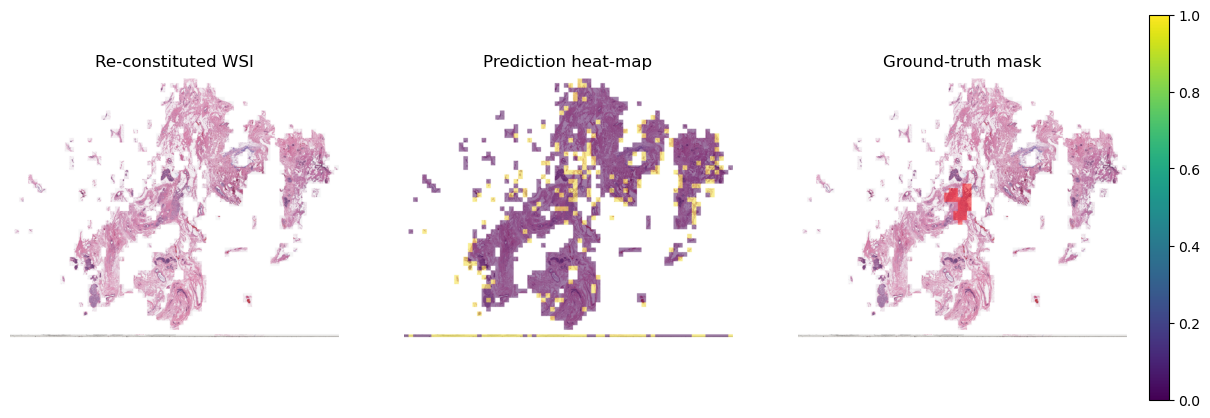

In [ ]:
random_wsis = ...
for wsi in random_wsis:
    plot_trio(wsi)

<span style="background-color: #FFD700">**Write your answer below**</span>

Answer here:

---

### Next Steps

The model failed to capture regions of interest for IDC in our dataset.

---
**GQ*7: Propose why this may be the case.**

<span style="background-color: #FFD700">**Write your answer below**</span>

Answer here:

---

To mitigate this issue and to actually give our model predictive power, we will **Fine-Tune** the TinyViT by training it on the ground-truth masks, and then evaluate it on a test set. We'll check back on this in the next module.